# Campus GAT V22-B

In [16]:
import os
!git -C swe3032 pull 2>/dev/null || git clone https://github.com/SKKUAIProjectTeam1/swe3032.git
os.chdir('swe3032')

Cloning into 'swe3032'...
remote: Enumerating objects: 1152, done.
remote: Counting objects: 100% (2/2), done.
remote: Total 1152 (delta 1), reused 1 (delta 1), pack-reused 1150 (from 1)
Receiving objects: 100% (1152/1152), 188.50 MiB | 39.30 MiB/s, done.
Resolving deltas: 100% (243/243), done.
Updating files: 100% (979/979), done.


In [17]:
import glob, os
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from scipy.ndimage import distance_transform_edt

print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Tesla T4


In [18]:
# ── 설정 ──────────────────────────────────────────────────────────────────────
RES           = 100
N             = RES * RES
NODE_DIM      = 5
GAT_HEADS     = 4
DIFF_STEPS    = 25
EPOCHS        = 300
LR            = 3e-4
WARMUP_EPOCHS = 50
ATTN_DROPOUT  = 0.1
ACCUM_STEPS   = 10
N_GATES       = 2
GATE_MIN_DIST = 14
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMG_DIR = 'collegemap/images'
TXT_DIR = 'collegemap/txt'
OUT_DIR = 'output'
CKPT    = os.path.join(OUT_DIR, 'v22b.pth')
os.makedirs(OUT_DIR, exist_ok=True)

In [19]:
# ── 고정 그래프 토폴로지 ───────────────────────────────────────────────────────
def _build_edges(res):
    edges = []
    for y in range(res):
        for x in range(res):
            s = y * res + x
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    if dy == 0 and dx == 0: continue
                    nx_, ny_ = x + dx, y + dy
                    if 0 <= nx_ < res and 0 <= ny_ < res:
                        edges.append((s, ny_ * res + nx_))
    edges += [(i, i) for i in range(res * res)]
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

EDGE_INDEX = _build_edges(RES).to(DEVICE)

_bdy = []
for i in range(10, RES - 10):
    _bdy += [i, (RES-1)*RES + i, i*RES, i*RES + (RES-1)]
BOUNDARY   = sorted(set(_bdy))
BOUNDARY_T = torch.tensor(BOUNDARY, dtype=torch.long).to(DEVICE)

In [20]:
# ── 데이터 로딩 ────────────────────────────────────────────────────────────────
def _find_txt(img_path):
    stem   = os.path.basename(img_path).replace('_building_mask.png', '')
    direct = os.path.join(TXT_DIR, stem + '_building_places.txt')
    if os.path.exists(direct): return direct
    prefix = stem.replace('-', '_').split('_')[0]
    for fn in os.listdir(TXT_DIR):
        if fn.endswith('_building_places.txt') and fn.startswith(prefix):
            return os.path.join(TXT_DIR, fn)
    return None

def _nearest_road_node(cy, cx, is_bld_grid):
    non_bld_yx = np.argwhere(is_bld_grid == 0)
    if len(non_bld_yx) == 0: return int(cy) * RES + int(cx)
    dists = (non_bld_yx[:,0] - cy)**2 + (non_bld_yx[:,1] - cx)**2
    best  = non_bld_yx[np.argmin(dists)]
    return int(best[0]) * RES + int(best[1])

def load_campus(img_path, txt_path):
    img    = Image.open(img_path).convert('L')
    W, H   = img.size
    is_bld = (np.array(img.resize((RES,RES), resample=Image.NEAREST)) > 128).astype(np.float32)
    dist   = distance_transform_edt(1 - is_bld)
    ridge  = ((dist > 1.5) & (dist < 7.0)).astype(np.float32)
    dist_n = (dist / (dist.max() or 1)).astype(np.float32)
    xs = np.tile(np.arange(RES), RES).astype(np.float32) / RES
    ys = np.repeat(np.arange(RES), RES).astype(np.float32) / RES
    node_feats = np.stack([is_bld.flatten(), ridge.flatten(), dist_n.flatten(), xs, ys], axis=1)
    ib_flat  = torch.tensor(is_bld.flatten(), dtype=torch.float32).to(DEVICE)
    src, dst = EDGE_INDEX[0], EDGE_INDEX[1]
    bld_mask = (ib_flat[src] > 0) | (ib_flat[dst] > 0)
    ns = {}
    exec(open(txt_path, encoding='utf-8').read(), ns)
    poly = ns['BUILDING_POLY']
    bld_nodes = list({_nearest_road_node(
        np.mean([p[1] for p in pts])*RES/H, np.mean([p[0] for p in pts])*RES/W, is_bld)
        for pts in poly.values()})
    return {
        'node_feats':     torch.tensor(node_feats, dtype=torch.float32).to(DEVICE),
        'is_building':    ib_flat, 'bld_mask': bld_mask,
        'ridge':          torch.tensor(ridge.flatten(), dtype=torch.float32).to(DEVICE),
        'building_nodes': torch.tensor(bld_nodes, dtype=torch.long).to(DEVICE),
        'poly': poly, 'name': os.path.basename(img_path).replace('_building_mask.png',''), 'W': W, 'H': H,
    }

campuses = []
for img_path in sorted(glob.glob(os.path.join(IMG_DIR, '*_building_mask.png'))):
    txt = _find_txt(img_path)
    if txt:
        try: campuses.append(load_campus(img_path, txt))
        except Exception as e: print(f'skip {os.path.basename(img_path)}: {e}')
print(f'{len(campuses)}개 캠퍼스 로드 완료')

100개 캠퍼스 로드 완료


In [21]:
# ── 모델 ──────────────────────────────────────────────────────────────────────
class MHGATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.0):
        super().__init__()
        assert out_dim % heads == 0
        self.heads = heads; self.dh = out_dim // heads
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.a_s  = nn.Parameter(torch.empty(heads, self.dh))
        self.a_d  = nn.Parameter(torch.empty(heads, self.dh))
        self.norm = nn.LayerNorm(out_dim)
        self.skip = nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity()
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight, gain=1.414)
        nn.init.xavier_normal_(self.a_s.unsqueeze(0)); nn.init.xavier_normal_(self.a_d.unsqueeze(0))

    def forward(self, x, ei):
        n = x.size(0); src, dst = ei[0], ei[1]
        h = self.W(x).view(n, self.heads, self.dh)
        e = F.leaky_relu((h[src]*self.a_s).sum(-1) + (h[dst]*self.a_d).sum(-1), 0.2)
        e_exp = torch.exp(e - e.max())
        denom = torch.zeros(n, self.heads, device=x.device)
        denom.scatter_add_(0, src.unsqueeze(1).expand(-1, self.heads), e_exp)
        alpha = self.drop(e_exp / (denom[src] + 1e-8))
        msg   = alpha.unsqueeze(-1) * h[dst]
        agg   = torch.zeros(n, self.heads, self.dh, device=x.device)
        agg.scatter_add_(0, src[:,None,None].expand_as(msg), msg)
        return self.norm(F.elu(agg.view(n,-1)) + self.skip(x))

class CampusGAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = MHGATLayer(NODE_DIM, 64, GAT_HEADS, ATTN_DROPOUT)
        self.gat2 = MHGATLayer(64, 64, GAT_HEADS, ATTN_DROPOUT)
        self.gat3 = MHGATLayer(64, 32, GAT_HEADS, ATTN_DROPOUT)
        self.edge_head = nn.Sequential(nn.Linear(128,32), nn.ReLU(), nn.Dropout(0.1), nn.Linear(32,1))
        self.gate_head = nn.Linear(32, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear) and m.bias is not None: nn.init.zeros_(m.bias)
        # sparse 초기화: sigmoid(-2)≈0.12 → 초기 ridge_loss 최소화
        nn.init.constant_(self.edge_head[-1].bias, -2.0)

    def forward(self, feats, ei, bld_mask):
        h1 = self.gat1(feats, ei); h2 = self.gat2(h1, ei); h3 = self.gat3(h2, ei)
        src, dst = ei[0], ei[1]
        ew = torch.sigmoid(self.edge_head(torch.cat([h2[src],h2[dst]],1)).squeeze(-1)) * (~bld_mask).float()
        gs = torch.sigmoid(self.gate_head(h3[BOUNDARY_T]).squeeze(-1))
        return ew, gs

model = CampusGAT().to(DEVICE)
print(f'파라미터: {sum(p.numel() for p in model.parameters()):,}개')

파라미터: 13,666개


In [22]:
# ── 손실 함수 ──────────────────────────────────────────────────────────────────
def diffusion_conn_loss(ew, building_nodes, T=DIFF_STEPS, weight=1.0):
    src, dst = EDGE_INDEX[0], EDGE_INDEX[1]
    n_bld = building_nodes.size(0)
    if n_bld <= 1: return ew.sum() * 0.
    signals = torch.zeros(N, n_bld, device=DEVICE)
    signals[building_nodes, torch.arange(n_bld, device=DEVICE)] = 1.0
    for _ in range(T):
        msg = torch.zeros(N, n_bld, device=DEVICE)
        msg.scatter_add_(0, dst.unsqueeze(1).expand(-1, n_bld), ew.unsqueeze(1)*signals[src])
        # steep sigmoid: 소멸 없이 장거리 전파
        signals = torch.sigmoid(10. * (signals + msg - 0.3))
    received = signals[building_nodes]
    off_diag = 1. - torch.eye(n_bld, device=DEVICE)
    return F.relu(1. - received).mul(off_diag).sum() * weight

def loss_fn(ew, gs, c, scale):
    src, dst = EDGE_INDEX[0], EDGE_INDEX[1]
    rs = (c['ridge'][src] + c['ridge'][dst]) * 0.5
    # mean: sum 대비 ~80,000배 스케일 감소
    ridge_loss = (ew * (1.-rs)).mean() * (scale*3. + 0.1)
    conn       = diffusion_conn_loss(ew, c['building_nodes'], weight=scale*20.+1.)
    sparse     = ew.mean() * 3.
    strength   = torch.zeros(N,device=DEVICE).scatter_add_(0,src,ew).scatter_add_(0,dst,ew)
    degree     = F.relu(strength - 4.).mean() * 300.
    gate       = (gs.sum() - N_GATES).pow(2) * 300.
    return ridge_loss + conn + sparse + degree + gate

In [23]:
# ── 학습 ──────────────────────────────────────────────────────────────────────
opt    = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sch    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=5e-6)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
n = len(campuses); loss_curve = []

for ep in range(1, EPOCHS+1):
    model.train(); scale = min(1.0, ep/WARMUP_EPOCHS); total = 0.; opt.zero_grad()
    for i, c in enumerate(campuses):
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            ew, gs = model(c['node_feats'], EDGE_INDEX, c['bld_mask'])
            loss   = loss_fn(ew, gs, c, scale) / n
        scaler.scale(loss).backward(); total += loss.item() * n
        if (i+1) % ACCUM_STEPS == 0 or (i+1) == n:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            scaler.step(opt); scaler.update(); opt.zero_grad()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
    sch.step(); loss_curve.append(total/n)
    if ep % 25 == 0 or ep == 1:
        print(f'[{ep:4d}/{EPOCHS}] loss={total/n:.2f}  lr={sch.get_last_lr()[0]:.2e}')

torch.save(model.state_dict(), CKPT)
print(f'저장: {CKPT}')

/tmp/ipykernel_1840/1693891420.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_1840/1693891420.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_1840/1693891420.py:19: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sch.step(); loss_curve.append(total/n)


[   1/300] loss=11167307.23  lr=3.00e-04
[  25/300] loss=0.60  lr=2.95e-04
[  50/300] loss=0.67  lr=2.80e-04
[  75/300] loss=0.68  lr=2.57e-04
[ 100/300] loss=0.68  lr=2.26e-04
[ 125/300] loss=0.67  lr=1.91e-04
[ 150/300] loss=0.66  lr=1.52e-04
[ 175/300] loss=0.65  lr=1.14e-04
[ 200/300] loss=0.65  lr=7.87e-05
[ 225/300] loss=0.72  lr=4.82e-05
[ 250/300] loss=0.72  lr=2.48e-05
[ 275/300] loss=0.72  lr=1.00e-05
[ 300/300] loss=0.72  lr=5.00e-06
저장: output/v22b.pth


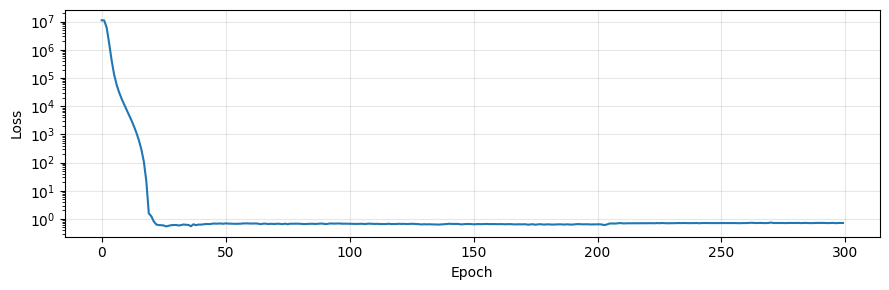

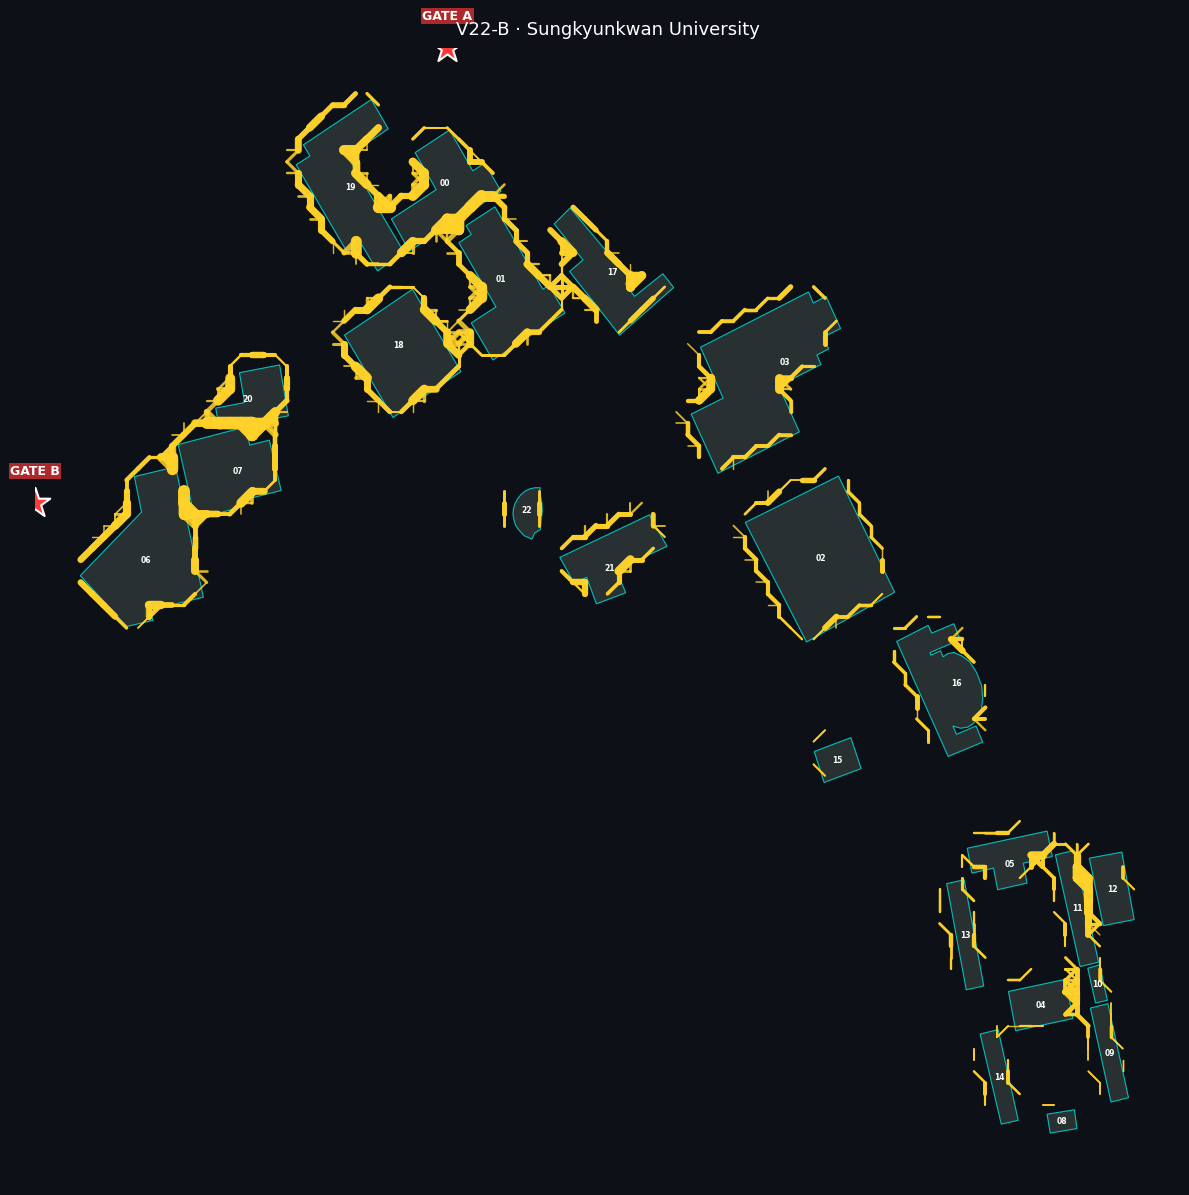

In [24]:
# ── 손실 커브 & 시각화 ─────────────────────────────────────────────────────────
plt.figure(figsize=(9,3)); plt.plot(loss_curve); plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def plot_campus(c):
    model.eval()
    with torch.no_grad():
        ew, gs = model(c['node_feats'], EDGE_INDEX, c['bld_mask'])
    ew_np=ew.cpu().numpy(); gs_np=gs.cpu().numpy(); ei=EDGE_INDEX.cpu(); ib_np=c['is_building'].cpu().numpy()
    W,H = c['W'],c['H']
    order=np.argsort(gs_np)[::-1]; chosen=[]
    for gi in order:
        gx=BOUNDARY[gi]%RES; gy=BOUNDARY[gi]//RES
        if all(abs(gx-BOUNDARY[p]%RES)+abs(gy-BOUNDARY[p]//RES)>=GATE_MIN_DIST for p in chosen):
            chosen.append(gi)
        if len(chosen)==N_GATES: break
    fig,ax=plt.subplots(figsize=(12,12)); ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
    for bid,pts in c['poly'].items():
        sc=[(p[0]*RES/W,p[1]*RES/H) for p in pts]
        ax.add_patch(mpatches.Polygon(sc,closed=True,facecolor='#2d3436',edgecolor='#00cec9',lw=0.8,alpha=0.9))
        ax.text(np.mean([p[0] for p in sc]),np.mean([p[1] for p in sc]),bid,color='white',ha='center',va='center',fontsize=5.5,fontweight='bold')
    thr=np.percentile(ew_np,98.5); mxw=max(ew_np.max(),thr+1e-8)
    for i in range(len(ew_np)):
        w=ew_np[i]
        if w<thr: continue
        s,d=ei[0,i].item(),ei[1,i].item()
        if ib_np[s]>0 or ib_np[d]>0: continue
        y1,x1=divmod(s,RES); y2,x2=divmod(d,RES)
        ax.plot([x1,x2],[y1,y2],color='#ffd32a',alpha=0.85,lw=(w-thr)/(mxw-thr)*8+1,solid_capstyle='round')
    for k,gi in enumerate(chosen):
        node=BOUNDARY[gi]; gx,gy=node%RES,node//RES
        ax.scatter(gx,gy,s=500,c='#ff3838',marker='*',edgecolors='white',lw=1.5,zorder=10)
        ax.text(gx,gy-2.5,f'GATE {chr(65+k)}',color='white',ha='center',fontsize=9,fontweight='bold',bbox=dict(fc='#d63031',alpha=0.8,ec='none',pad=1))
    ax.set_xlim(0,RES); ax.set_ylim(RES,0); ax.axis('off')
    ax.set_title(f'V22-B · {c["name"].replace("_"," ").title()}',color='white',fontsize=13,pad=10)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR,f'v22b_{c["name"]}.png'),dpi=150,bbox_inches='tight',facecolor='#0d1117')
    plt.show(); plt.close()

# 특정 캠퍼스 확인
TARGET = 'sungkyunkwan_university'
target = next((c for c in campuses if TARGET in c['name']), None)
if target: plot_campus(target)